In [1]:
!pip install scikit-learn pandas numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load Hubei dataset
hubei = pd.read_csv(r"C:\Users\Sneha Srishti\Desktop\hubei_carbon.csv")

# Load EU ETS dataset (adjust path to where you saved it)
eu = pd.read_csv(r"D:\Downloads\Carbon Emissions Futures Historical Data (1).csv")

print("Hubei shape:", hubei.shape)
print("EU ETS shape:", eu.shape)
print("\nHubei columns:", hubei.columns.tolist())
print("EU ETS columns:", eu.columns.tolist())

Hubei shape: (1852, 5)
EU ETS shape: (2836, 7)

Hubei columns: ['Date', 'Close_Price', 'Volume', 'Turnover', 'Market']
EU ETS columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


In [5]:
# ── Hubei ──────────────────────────────────────────
# Parse dates
hubei['Date'] = pd.to_datetime(hubei['Date'])
hubei = hubei.sort_values('Date').reset_index(drop=True)

# Compute Price Change %
hubei['Change_Pct'] = hubei['Close_Price'].pct_change() * 100

# Forward fill missing values (standard for carbon markets)
hubei = hubei.fillna(method='ffill')

# Drop rows where Close_Price is still 0 (non-trading days)
hubei = hubei[hubei['Close_Price'] > 0].reset_index(drop=True)

# Outlier removal using Z-score on Close_Price
z_scores = (hubei['Close_Price'] - hubei['Close_Price'].mean()) / hubei['Close_Price'].std()
hubei = hubei[abs(z_scores) < 3].reset_index(drop=True)

print("Hubei after cleaning:", hubei.shape)
print(hubei.head())

Hubei after cleaning: (1841, 6)
        Date  Close_Price    Volume    Turnover Market  Change_Pct
0 2014-04-02    21.000000  510020.0  10710400.0     湖北         NaN
1 2014-04-03    24.200001   51468.0   1245530.0     湖北   15.238099
2 2014-04-04    26.620001  304125.0   8092670.0     湖北   10.000000
3 2014-04-05    26.620001       0.0         0.0     湖北    0.000000
4 2014-04-06    26.620001       0.0         0.0     湖北    0.000000


In [6]:
# ── EU ETS ─────────────────────────────────────────
# investing.com CSV often has commas in numbers — clean them
eu.columns = eu.columns.str.strip()
eu['Price'] = eu['Price'].astype(str).str.replace(',', '').astype(float)
eu['Open']  = eu['Open'].astype(str).str.replace(',', '').astype(float)
eu['High']  = eu['High'].astype(str).str.replace(',', '').astype(float)
eu['Low']   = eu['Low'].astype(str).str.replace(',', '').astype(float)
eu['Vol.']  = eu['Vol.'].astype(str).str.replace(',', '').str.replace('K','').astype(float)
eu['Change %'] = eu['Change %'].astype(str).str.replace('%','').astype(float)

# Rename to standard names
eu = eu.rename(columns={
    'Price':    'Close_Price',
    'Vol.':     'Volume',
    'Change %': 'Change_Pct'
})

# Parse and sort dates
eu['Date'] = pd.to_datetime(eu['Date'])
eu = eu.sort_values('Date').reset_index(drop=True)

# Forward fill
eu = eu.fillna(method='ffill')

# Outlier removal
z_scores = (eu['Close_Price'] - eu['Close_Price'].mean()) / eu['Close_Price'].std()
eu = eu[abs(z_scores) < 3].reset_index(drop=True)

print("EU ETS after cleaning:", eu.shape)
print(eu.head())

EU ETS after cleaning: (2836, 7)
        Date  Close_Price  Open  High   Low  Volume  Change_Pct
0 2014-01-01         4.93  4.93  4.93  4.93     NaN        2.17
1 2014-01-02         4.71  4.83  4.83  4.75    0.01       -4.56
2 2014-01-03         4.69  4.69  4.69  4.69    0.15       -0.42
3 2014-01-06         4.61  4.70  4.70  4.70    0.05       -1.71
4 2014-01-07         4.66  4.65  4.70  4.65    0.02        1.08


In [7]:
def normalize_dataset(df, feature_cols):
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])
    return df_scaled, scaler

# Features to normalize
hubei_features = ['Close_Price', 'Volume', 'Turnover', 'Change_Pct']
eu_features    = ['Close_Price', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']

hubei_scaled, hubei_scaler = normalize_dataset(hubei, hubei_features)
eu_scaled, eu_scaler       = normalize_dataset(eu, eu_features)

print("✅ Normalization done")
print(hubei_scaled[hubei_features].describe().round(3))

✅ Normalization done
       Close_Price    Volume  Turnover  Change_Pct
count     1841.000  1841.000  1841.000    1840.000
mean         0.427     0.021     0.031       0.334
std          0.192     0.046     0.062       0.035
min          0.000     0.000     0.000       0.000
25%          0.231     0.000     0.001       0.326
50%          0.453     0.006     0.010       0.334
75%          0.562     0.024     0.036       0.342
max          1.000     1.000     1.000       1.000


In [8]:
def split_dataset(df):
    n = len(df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.80)

    train = df.iloc[:train_end]
    val   = df.iloc[train_end:val_end]
    test  = df.iloc[val_end:]

    print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
    return train, val, test

print("── Hubei ──")
hubei_train, hubei_val, hubei_test = split_dataset(hubei_scaled)

print("── EU ETS ──")
eu_train, eu_val, eu_test = split_dataset(eu_scaled)

── Hubei ──
Train: 1288 | Val: 184 | Test: 369
── EU ETS ──
Train: 1985 | Val: 283 | Test: 568


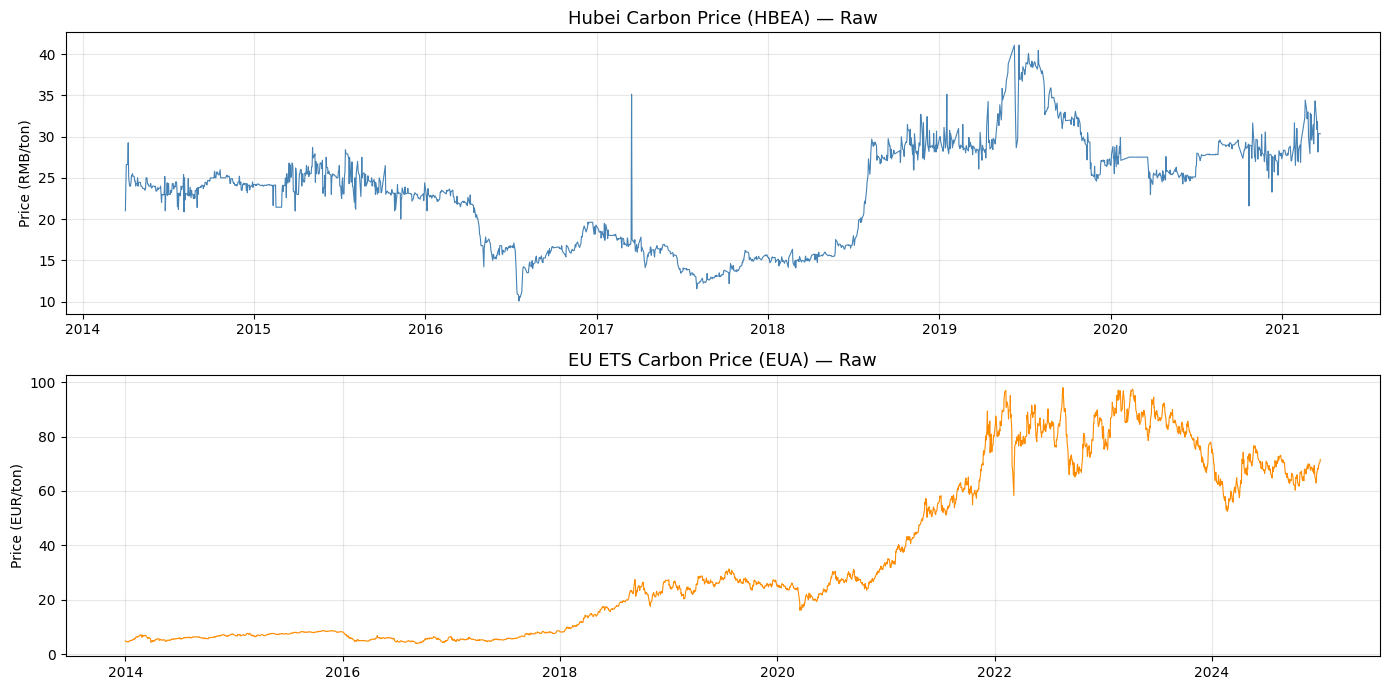

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(hubei['Date'], hubei['Close_Price'], color='steelblue', linewidth=0.8)
axes[0].set_title('Hubei Carbon Price (HBEA) — Raw', fontsize=13)
axes[0].set_ylabel('Price (RMB/ton)')
axes[0].grid(alpha=0.3)

axes[1].plot(eu['Date'], eu['Close_Price'], color='darkorange', linewidth=0.8)
axes[1].set_title('EU ETS Carbon Price (EUA) — Raw', fontsize=13)
axes[1].set_ylabel('Price (EUR/ton)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('carbon_prices_overview.png', dpi=150)
plt.show()


In [13]:
hubei_scaled.to_csv(r"C:\Users\Sneha Srishti\Desktop\hubei_clean.csv", index=False)
eu_scaled.to_csv(r"C:\Users\Sneha Srishti\Desktop\eu_ets_clean.csv", index=False)


In [11]:
!pip install xgboost torch scikit-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 214.3 kB/s eta 0:07:52
   ---------------------------------------- 0.5/101.7 MB 214.3 kB/s eta 0:07:52
   ---------------------------------------- 0.5/101.7 MB 214.3 kB/s eta 0:07:52
   ---------------------------------------- 0.8/101.7 MB 282.4 kB/s eta 0:05:58
   --------------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
def create_sequences(data, target_col, seq_len=30):
    X, y = [], []
    values = data[target_col].values
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len])
        y.append(values[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 30  # Use 30 days of history to predict next day

# Hubei sequences
X_hubei_train, y_hubei_train = create_sequences(hubei_train, 'Close_Price', SEQ_LEN)
X_hubei_val,   y_hubei_val   = create_sequences(hubei_val,   'Close_Price', SEQ_LEN)
X_hubei_test,  y_hubei_test  = create_sequences(hubei_test,  'Close_Price', SEQ_LEN)

# EU ETS sequences
X_eu_train, y_eu_train = create_sequences(eu_train, 'Close_Price', SEQ_LEN)
X_eu_val,   y_eu_val   = create_sequences(eu_val,   'Close_Price', SEQ_LEN)
X_eu_test,  y_eu_test  = create_sequences(eu_test,  'Close_Price', SEQ_LEN)

print("Hubei  → X_train:", X_hubei_train.shape, "| X_test:", X_hubei_test.shape)
print("EU ETS → X_train:", X_eu_train.shape,    "| X_test:", X_eu_test.shape)

Hubei  → X_train: (1258, 30) | X_test: (339, 30)
EU ETS → X_train: (1955, 30) | X_test: (538, 30)


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_lstm(X_train, y_train, X_val, y_val, epochs=50, lr=0.001):
    # Convert to tensors
    X_tr = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
    y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_v  = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
    y_v  = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(-1)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=False)

    model     = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_pred = model(X_v)
            val_loss = criterion(val_pred, y_v).item()

        train_losses.append(epoch_loss / len(loader))
        val_losses.append(val_loss)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.5f} | Val Loss: {val_loss:.5f}")

    return model, train_losses, val_losses



In [18]:
print("── Training LSTM on Hubei ──")
lstm_hubei, tl_h, vl_h = train_lstm(X_hubei_train, y_hubei_train, 
                                      X_hubei_val,   y_hubei_val, epochs=50)

print("\n── Training LSTM on EU ETS ──")
lstm_eu, tl_e, vl_e = train_lstm(X_eu_train, y_eu_train,
                                   X_eu_val,   y_eu_val, epochs=50)

── Training LSTM on Hubei ──
Epoch 10/50 | Train Loss: 0.01065 | Val Loss: 0.09863
Epoch 20/50 | Train Loss: 0.00370 | Val Loss: 0.04012
Epoch 30/50 | Train Loss: 0.00275 | Val Loss: 0.02779
Epoch 40/50 | Train Loss: 0.00258 | Val Loss: 0.02261
Epoch 50/50 | Train Loss: 0.00216 | Val Loss: 0.01623

── Training LSTM on EU ETS ──
Epoch 10/50 | Train Loss: 0.00300 | Val Loss: 0.00316
Epoch 20/50 | Train Loss: 0.00082 | Val Loss: 0.00274
Epoch 30/50 | Train Loss: 0.00038 | Val Loss: 0.00321
Epoch 40/50 | Train Loss: 0.00199 | Val Loss: 0.00253
Epoch 50/50 | Train Loss: 0.00114 | Val Loss: 0.00431


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_lstm(model, X_test, y_test, scaler, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
    with torch.no_grad():
        preds = model(X_t).numpy().flatten()

    # Inverse transform to get real prices
    preds_real  = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
    mae  = mean_absolute_error(y_test_real, preds_real)
    mape = mean_absolute_percentage_error(y_test_real, preds_real)

    print(f" LSTM — {label}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   MAPE : {mape:.4f}%")
    return preds_real, y_test_real, rmse, mae, mape

# Need a price-only scaler for inverse transform
hubei_price_scaler = MinMaxScaler()
hubei_price_scaler.fit(hubei[['Close_Price']])

eu_price_scaler = MinMaxScaler()
eu_price_scaler.fit(eu[['Close_Price']])

preds_lstm_hubei, actual_hubei, rmse_lh, mae_lh, mape_lh = evaluate_lstm(
    lstm_hubei, X_hubei_test, y_hubei_test, hubei_price_scaler, "Hubei")

preds_lstm_eu, actual_eu, rmse_le, mae_le, mape_le = evaluate_lstm(
    lstm_eu, X_eu_test, y_eu_test, eu_price_scaler, "EU ETS")

 LSTM — Hubei
   RMSE : 2.3599
   MAE  : 2.1301
   MAPE : 7.5673%
 LSTM — EU ETS
   RMSE : 4.9300
   MAE  : 3.8335
   MAPE : 4.7266%


In [20]:
from xgboost import XGBRegressor

def train_xgboost(X_train, y_train, X_test, y_test, scaler, label):
    # XGBoost takes 2D input — flatten sequences
    X_tr_flat = X_train.reshape(X_train.shape[0], -1)
    X_te_flat = X_test.reshape(X_test.shape[0], -1)

    model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                         max_depth=5, random_state=42, verbosity=0)
    model.fit(X_tr_flat, y_train)

    preds = model.predict(X_te_flat)

    # Inverse transform
    preds_real  = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
    mae  = mean_absolute_error(y_test_real, preds_real)
    mape = mean_absolute_percentage_error(y_test_real, preds_real)

    print(f"XGBoost — {label}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   MAPE : {mape:.4f}%")
    return preds_real, y_test_real, rmse, mae, mape

preds_xgb_hubei, _, rmse_xh, mae_xh, mape_xh = train_xgboost(
    X_hubei_train, y_hubei_train, X_hubei_test, y_hubei_test, hubei_price_scaler, "Hubei")

preds_xgb_eu, _, rmse_xe, mae_xe, mape_xe = train_xgboost(
    X_eu_train, y_eu_train, X_eu_test, y_eu_test, eu_price_scaler, "EU ETS")

XGBoost — Hubei
   RMSE : 1.6376
   MAE  : 1.0911
   MAPE : 3.8290%
XGBoost — EU ETS
   RMSE : 17.0890
   MAE  : 13.8236
   MAPE : 16.6992%


In [21]:
results = pd.DataFrame({
    'Model':   ['LSTM', 'LSTM', 'XGBoost', 'XGBoost'],
    'Dataset': ['Hubei', 'EU ETS', 'Hubei', 'EU ETS'],
    'RMSE':    [rmse_lh, rmse_le, rmse_xh, rmse_xe],
    'MAE':     [mae_lh,  mae_le,  mae_xh,  mae_xe],
    'MAPE(%)': [mape_lh, mape_le, mape_xh, mape_xe]
})
print("Baseline Results Summary")
print(results.round(4).to_string(index=False))

Baseline Results Summary
  Model Dataset    RMSE     MAE  MAPE(%)
   LSTM   Hubei  2.3599  2.1301   7.5673
   LSTM  EU ETS  4.9300  3.8335   4.7266
XGBoost   Hubei  1.6376  1.0911   3.8290
XGBoost  EU ETS 17.0890 13.8236  16.6992


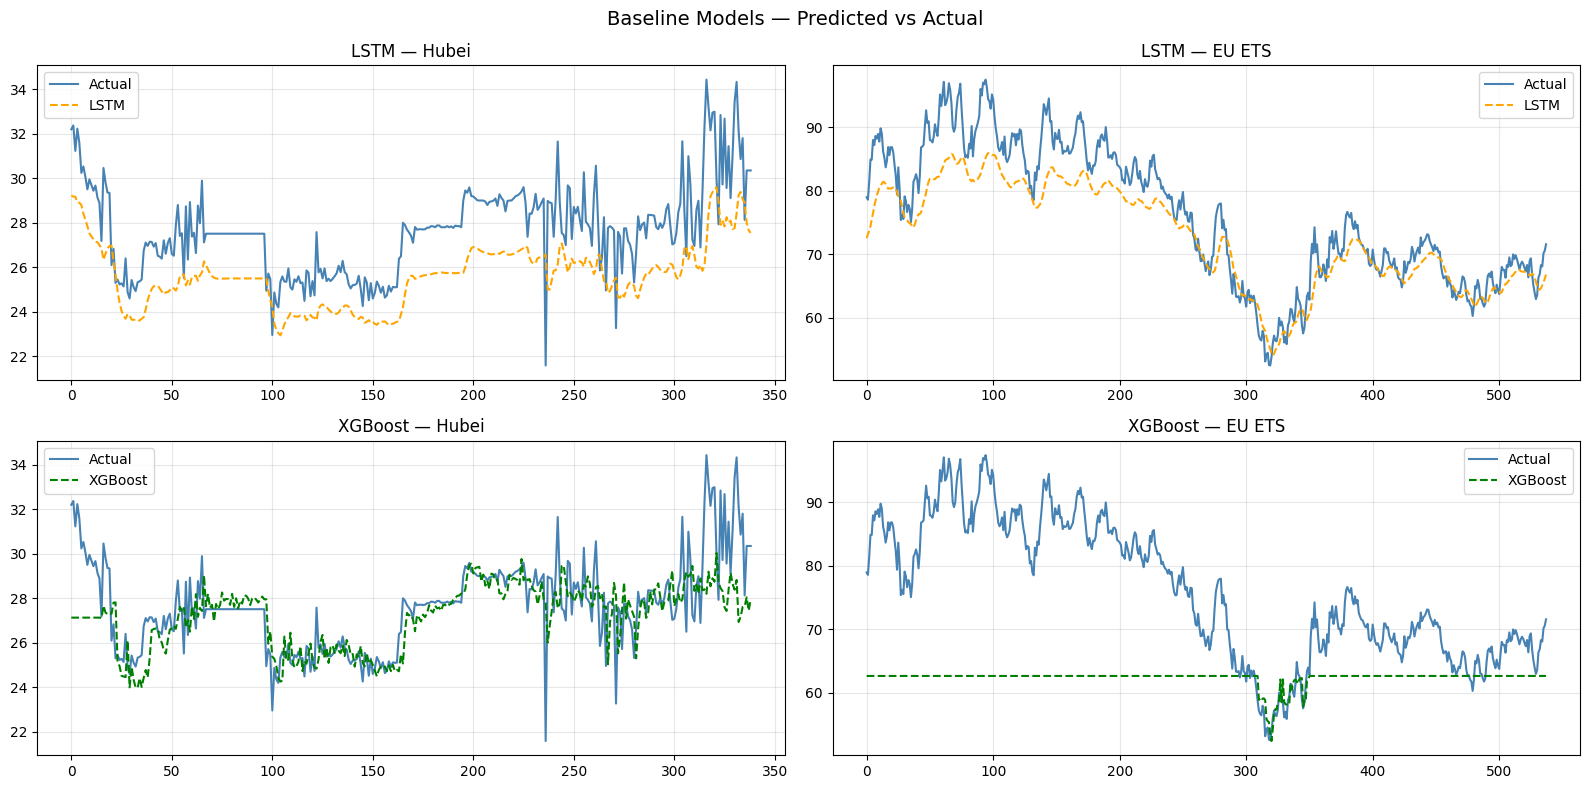

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].plot(actual_hubei,      label='Actual',  color='steelblue')
axes[0,0].plot(preds_lstm_hubei,  label='LSTM',    color='orange', linestyle='--')
axes[0,0].set_title('LSTM — Hubei'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(actual_eu,         label='Actual',  color='steelblue')
axes[0,1].plot(preds_lstm_eu,     label='LSTM',    color='orange', linestyle='--')
axes[0,1].set_title('LSTM — EU ETS'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(actual_hubei,      label='Actual',  color='steelblue')
axes[1,0].plot(preds_xgb_hubei,   label='XGBoost', color='green',  linestyle='--')
axes[1,0].set_title('XGBoost — Hubei'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(actual_eu,         label='Actual',  color='steelblue')
axes[1,1].plot(preds_xgb_eu,      label='XGBoost', color='green',  linestyle='--')
axes[1,1].set_title('XGBoost — EU ETS'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle('Baseline Models — Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150)
plt.show()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SeriesDecomposition(nn.Module):
    """
    Decomposes input into trend + seasonal components
    using a moving average kernel — replaces manual EMD/VMD
    """
    def __init__(self, kernel_size=25):
        super(SeriesDecomposition, self).__init__()
        self.kernel_size = kernel_size
        # Padding to keep same sequence length
        self.avg_pool = nn.AvgPool1d(
            kernel_size=kernel_size, 
            stride=1, 
            padding=kernel_size//2
        )

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        x_t = x.permute(0, 2, 1)                    # → (batch, features, seq_len)
        trend = self.avg_pool(x_t)                   # extract trend
        # Fix length mismatch from padding
        if trend.shape[-1] != x_t.shape[-1]:
            trend = trend[:, :, :x_t.shape[-1]]
        trend    = trend.permute(0, 2, 1)            # → (batch, seq_len, features)
        seasonal = x - trend                         # residual = seasonal
        return seasonal, trend


In [2]:
class SpatioTemporalAttention(nn.Module):
    
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super(SpatioTemporalAttention, self).__init__()

        # Temporal attention — standard multi-head over time steps
        self.temporal_attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        # Spatial attention — multi-head over feature dimension
        self.spatial_attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )

        # Project concatenated output back to d_model
        self.proj    = nn.Linear(d_model * 2, d_model)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Temporal attention
        t_out, _ = self.temporal_attn(x, x, x)
        t_out    = self.norm1(x + self.dropout(t_out))

        # Spatial attention — transpose so features become sequence
        x_t      = x.permute(0, 2, 1)
        s_out, _ = self.spatial_attn(x_t, x_t, x_t)
        s_out    = s_out.permute(0, 2, 1)
        s_out    = self.norm2(x + self.dropout(s_out))

        # Fuse both
        fused = torch.cat([t_out, s_out], dim=-1)   # (batch, seq, d_model*2)
        out   = self.proj(fused)                     # (batch, seq, d_model)
        return out



In [ ]:
class CarbonTransformer(nn.Module):
    def __init__(self, 
                 input_size=1, 
                 d_model=64, 
                 n_heads=4, 
                 n_layers=2,
                 ff_dim=256,
                 seq_len=30,
                 dropout=0.1):
        super(CarbonTransformer, self).__init__()

        self.input_proj  = nn.Linear(input_size, d_model)
        self.decomp      = SeriesDecomposition(kernel_size=25)
        self.pos_dropout = nn.Dropout(dropout)
        self.d_model     = d_model  # store for dynamic PE

        self.st_layers = nn.ModuleList([
            SpatioTemporalAttention(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.norm        = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, 1)

    def get_positional_encoding(self, seq_len, d_model, device):
        """Generate PE dynamically based on actual input length"""
        pe  = torch.zeros(seq_len, d_model, device=device)
        pos = torch.arange(0, seq_len, device=device).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2, device=device).float() *
                        -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)  # (1, seq_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_proj(x)                          # (batch, seq, d_model)

        seasonal, trend = self.decomp(x)

        pe = self.get_positional_encoding(x.shape[1], self.d_model, x.device)
        x  = seasonal + pe
        x  = self.pos_dropout(x)

        for layer in self.st_layers:
            x = layer(x)

        x   = self.norm(x + self.ffn(x))
        x   = x + trend
        out = self.output_proj(x[:, -1, :])
        return out



In [4]:
def train_transformer(X_train, y_train, X_val, y_val, 
                       epochs=100, lr=0.001, patience=10):

    # Tensors
    X_tr = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
    y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_v  = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
    y_v  = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(-1)

    loader = DataLoader(TensorDataset(X_tr, y_tr), 
                        batch_size=32, shuffle=False)

    model     = CarbonTransformer(input_size=1, d_model=64, 
                                   n_heads=4, n_layers=2, seq_len=SEQ_LEN)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                  betas=(0.9, 0.999))  # PSO will tune these later

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_v)
            val_loss = criterion(val_pred, y_v).item()

        avg_train = epoch_loss / len(loader)
        train_losses.append(avg_train)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"   Early stopping at epoch {epoch+1}")
                break

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:>3} | Train: {avg_train:.5f} | Val: {val_loss:.5f}")

    # Restore best model
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


In [5]:
print("── Training Transformer on Hubei ──")
transformer_hubei, tl_th, vl_th = train_transformer(
    X_hubei_train, y_hubei_train,
    X_hubei_val,   y_hubei_val,
    epochs=100, lr=0.001
)

print("\n── Training Transformer on EU ETS ──")
transformer_eu, tl_te, vl_te = train_transformer(
    X_eu_train, y_eu_train,
    X_eu_val,   y_eu_val,
    epochs=100, lr=0.001
)

── Training Transformer on Hubei ──


NameError: name 'X_hubei_train' is not defined